In [1]:
# traderie_analysis_cell.py

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
file_path = '/Users/buddy/Desktop/traderie/data/completed_trades_pc_sc_nl.json'

with open(file_path, 'r') as f:
    raw_data = json.load(f)

# Parse to DataFrame
records = []
for trade, content in raw_data.items():
    offer, ask = trade.split(':')
    meta = content.get('metadata', {})
    records.append({
        'Offer': offer,
        'Ask': ask,
        'Total Trades': meta.get('total_trades', 0),
        'Most Common Ratio': meta.get('most_common', ''),
        'Median Ratio': meta.get('median_ratio', 0),
        'Weighted Avg': meta.get('weighted_avg', 0),
        'Recommended Ratio': meta.get('recommended_ratio', ''),
        'Low Confidence': meta.get('low_confidence', False),
        'Last Updated': meta.get('last_updated', '')
    })

df = pd.DataFrame(records)
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

# Preview
print("These are completed trades from traderie.com, ")

print("Basic Info:")
print(df.info())
print(df.head())

These are completed trades from traderie.com, 
Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   Offer              418 non-null    object             
 1   Ask                418 non-null    object             
 2   Total Trades       418 non-null    int64              
 3   Most Common Ratio  418 non-null    object             
 4   Median Ratio       418 non-null    float64            
 5   Weighted Avg       418 non-null    float64            
 6   Recommended Ratio  418 non-null    object             
 7   Low Confidence     418 non-null    bool               
 8   Last Updated       418 non-null    datetime64[ns, UTC]
dtypes: bool(1), datetime64[ns, UTC](1), float64(2), int64(1), object(4)
memory usage: 26.7+ KB
None
      Offer                  Ask  Total Trades Most Common Ratio  \
0  Ist R

In [2]:
# Condensed Output Summary for GPT Planning

from collections import defaultdict
from datetime import datetime, timezone

# Compile all trades involving selected rune
selected_rune = 'Jah Rune'  # Change this to any rune to explore

# Build a dictionary of relevant trades
trade_summaries = defaultdict(list)

for trade_key, content in raw_data.items():
    offer, ask = trade_key.split(':')
    if selected_rune in (offer, ask):
        for ratio_str, ratio_info in content.get('ratios', {}).items():
            count = ratio_info['count']
            last_seen = ratio_info['last_seen']
            time_ago = pd.Timestamp.now(tz=timezone.utc) - pd.to_datetime(last_seen)
            hours_ago = int(time_ago.total_seconds() // 3600)
            recent_str = f"{ratio_str} ({hours_ago}h ago)"
            trade_summaries[f"{offer} : {ask}"].append(recent_str)

# Format output
print(f"{selected_rune} Trades\n")
for pair, summaries in sorted(trade_summaries.items(), key=lambda x: -len(x[1])):
    print(f"{pair}")
    for line in summaries:
        print(f"  {line}")
    print()

Jah Rune Trades

Ber Rune : Jah Rune
  3:1 (635h ago)
  2:2 (541h ago)
  1:1 (545h ago)
  3:3 (633h ago)
  5:5 (542h ago)
  4:1 (595h ago)
  22:20 (660h ago)
  20:17 (569h ago)
  10:10 (602h ago)
  16:1 (667h ago)
  21:20 (597h ago)
  140:33 (624h ago)
  14:14 (633h ago)
  2:1 (543h ago)
  7:5 (639h ago)
  4:3 (639h ago)
  12:11 (639h ago)
  15:15 (656h ago)
  11:10 (597h ago)
  8:7 (613h ago)
  20:18 (544h ago)
  140:30 (613h ago)
  30:25 (601h ago)
  30:21 (602h ago)
  100:1 (588h ago)
  6:5 (589h ago)
  20:20 (594h ago)
  40:40 (612h ago)
  50:1 (550h ago)
  3:2 (552h ago)
  6:6 (564h ago)
  40:33 (572h ago)
  7:6 (578h ago)
  20:19 (578h ago)
  40:39 (578h ago)
  5:4 (588h ago)
  10:9 (544h ago)
  6:1 (609h ago)

Hel Rune : Jah Rune
  100:3 (654h ago)
  30:1 (560h ago)
  61:2 (658h ago)
  35:1 (554h ago)
  50:2 (552h ago)
  25:1 (552h ago)
  60:2 (663h ago)
  1:1 (665h ago)
  140:5 (565h ago)
  140:4 (580h ago)
  33:1 (554h ago)
  57:2 (680h ago)
  56:2 (685h ago)
  55:2 (616h ago)

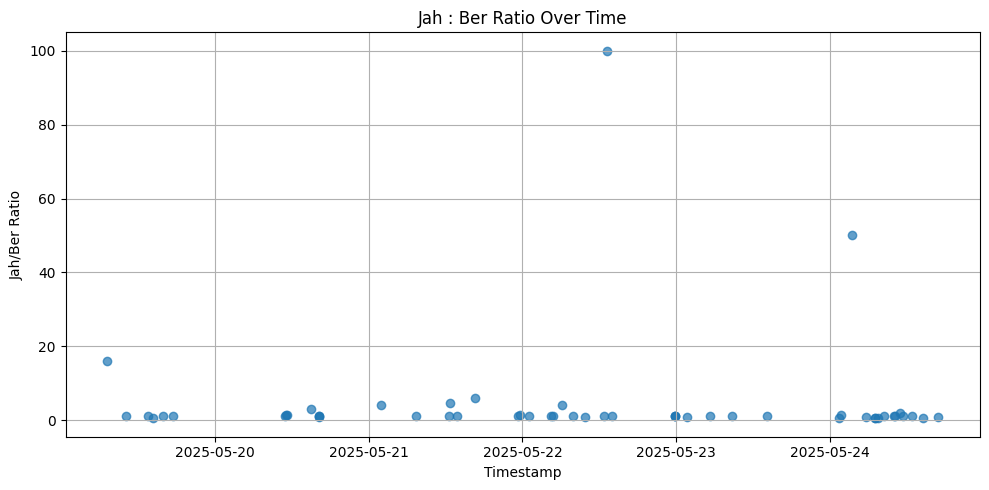

Descriptive Statistics (Jah : Ber ratio):
Count : 52
Mean  : 4.49
Std   : 15.25
Min   : 0.50
25%   : 1.00
50%   : 1.05 (Median)
75%   : 1.27
Max   : 100.00


In [10]:
# plot_jah_ber_ratio.py

import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timezone

# Load data
file_path = '/Users/buddy/Desktop/traderie/data/completed_trades_pc_sc_nl.json'  # Update with actual path
with open(file_path, 'r') as f:
    raw_data = json.load(f)



# Extract Jah : Ber ratios with timestamps
records = []
for trade_key, content in raw_data.items():
    offer, ask = trade_key.split(':')
    if {'Jah Rune', 'Ber Rune'} == {offer.strip(), ask.strip()}:
        for ratio_str, info in content.get('ratios', {}).items():
            last_seen = pd.to_datetime(info['last_seen']).tz_convert(timezone.utc)
            try:
                offer_amt, ask_amt = map(float, ratio_str.split(':'))
                ratio = offer_amt / ask_amt if ask_amt != 0 else None
            except:
                continue
            if ratio is not None:
                records.append({'timestamp': last_seen, 'ratio': ratio})

# Create DataFrame
df = pd.DataFrame(records).sort_values('timestamp')

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(df['timestamp'], df['ratio'], alpha=0.7)
plt.title('Jah : Ber Ratio Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Jah/Ber Ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

# Descriptive statistics
desc = df['ratio'].describe()
print("Descriptive Statistics (Jah : Ber ratio):")
print(f"Count : {desc['count']:.0f}")
print(f"Mean  : {desc['mean']:.2f}")
print(f"Std   : {desc['std']:.2f}")
print(f"Min   : {desc['min']:.2f}")
print(f"25%   : {desc['25%']:.2f}")
print(f"50%   : {desc['50%']:.2f} (Median)")
print(f"75%   : {desc['75%']:.2f}")
print(f"Max   : {desc['max']:.2f}")

In [11]:

# Compute mean and std
mean = df['ratio'].mean()
std = df['ratio'].std()

# Count outliers at varying sigma levels
for sigma in [1, 2, 3]:
    lower = mean - sigma * std
    upper = mean + sigma * std
    outliers = df[(df['ratio'] < lower) | (df['ratio'] > upper)]
    print(f"Outliers beyond ±{sigma}σ: {len(outliers)}")

# Optional: list extreme outliers
extreme_outliers = df[(df['ratio'] > mean + 3 * std) | (df['ratio'] < mean - 3 * std)]
print("\nExtreme Outliers (±3σ):")
print(extreme_outliers.sort_values('ratio'))

Outliers beyond ±1σ: 2
Outliers beyond ±2σ: 2
Outliers beyond ±3σ: 1

Extreme Outliers (±3σ):
                          timestamp  ratio
24 2025-05-22 13:16:27.356000+00:00  100.0


Jah:Ber Ratio Counts by Deviation from 1:1
±0.1: 4
±0.25: 16
±0.5: 10
±1: 1
±2: 1
±5: 4
±10: 0
>10: 3


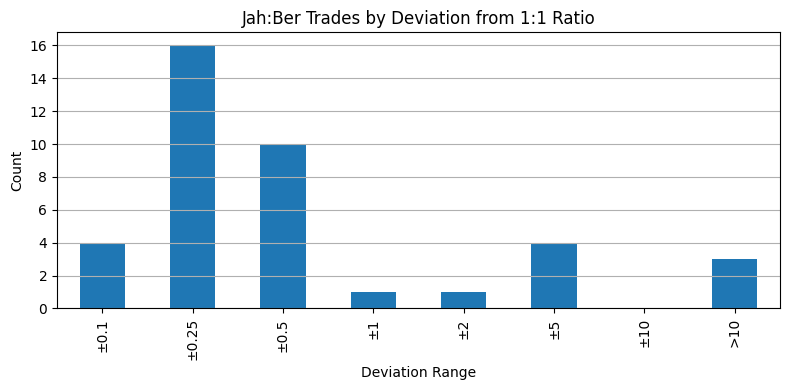

In [12]:
df = pd.DataFrame(records)
df['deviation'] = abs(df['ratio'] - 1.0)

# Bin deviations from 1.0
bins = [0, 0.1, 0.25, 0.5, 1, 2, 5, 10, float('inf')]
labels = ["±0.1", "±0.25", "±0.5", "±1", "±2", "±5", "±10", ">10"]
df['range'] = pd.cut(df['deviation'], bins=bins, labels=labels, right=True)

# Count by range
range_counts = df['range'].value_counts().sort_index()

# Print results
print("Jah:Ber Ratio Counts by Deviation from 1:1")
for label in labels:
    print(f"{label}: {range_counts.get(label, 0)}")

# Optional bar plot
plt.figure(figsize=(8, 4))
range_counts.plot(kind='bar')
plt.title('Jah:Ber Trades by Deviation from 1:1 Ratio')
plt.xlabel('Deviation Range')
plt.ylabel('Count')
plt.grid(axis='y')
plt.tight_layout()
plt.show()